## Computational Finance Lab Assignment 3
### Finite Difference Method for Option Pricing
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import norm

sns.set_theme()

## Class

In [ ]:
class FDM:
    def __init__(self, S0, K, T, r, sigma, M, N):
        self.S0 = S0      
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.M = M
        self.N = N
        self.sMax = 3 * S0
        self.dS = self.sMax / M
        self.dt = T / N
        self.grid = np.zeros((M + 1, N + 1))
        self.S_vals = [i * self.dS for i in range(M + 1)]
        self.T_vals = [j * self.dt for j in range(N + 1)]
    
    def bc_call(self, j):
            self.grid[self.M][j] = self.sMax - self.K*np.exp(-self.r*(self.T-self.T_vals[j]))
            self.grid[0][j] = 0

    def bc_put(self, j):
            self.grid[0][j] = self.K*np.exp(-self.r*(self.T-self.T_vals[j]))
            self.grid[self.M][j] = 0

    def explicit(self, option):
        stability = self.dS**2/(2*self.sigma**2*self.sMax**2)
        # if self.dt > stability:
            # print("Warning: The explicit method may be unstable with the current parameters.")
        for i in range(self.M+1):
            if option=="call":
                self.grid[i][self.N] = max(0, self.S_vals[i] - self.K)
            else:
                self.grid[i][self.N] = max(0, self.K - self.S_vals[i])

        for j in range(self.N-1, -1, -1):
            for i in range(1, self.M):
                a = self.dt/2*(self.sigma**2*i**2 - self.r*i)
                b = 1 - self.dt*(self.sigma**2*i**2 + self.r)
                c = self.dt/2*(self.r*i + self.sigma**2*i**2)
                self.grid[i][j] = a*self.grid[i-1][j+1] + b*self.grid[i][j+1] + c*self.grid[i+1][j+1]
            if option == 'call':
                self.bc_call(j)
            else:
                self.bc_put(j)        

    def implicit(self, option):
        for i in range(self.M+1):
            if option=="call":
                self.grid[i][self.N] = max(0, self.S_vals[i] - self.K)
            else:
                self.grid[i][self.N] = max(0, self.K - self.S_vals[i])

        for j in range(self.N-1, -1, -1):
            a = np.zeros(self.M-1)
            b = np.zeros(self.M-1)
            c = np.zeros(self.M-1)
            d = np.zeros(self.M-1)
            cp = np.zeros(self.M-1)
            dp = np.zeros(self.M-1)
            x = np.zeros(self.M-1)
            for i in range(1, self.M):
                a[i-1] = self.dt/2*(self.r*i - self.sigma**2*i**2)
                b[i-1] = 1 + self.dt*(self.sigma**2*i**2 + self.r)
                c[i-1] = -self.dt/2*(self.r*i + self.sigma**2*i**2)
                d[i-1] = self.grid[i][j+1]
            if option == 'call':
                d[-1] -= c[-1]*(self.sMax - self.K*np.exp(-self.r*(self.T-self.T_vals[j])))
            else:       
                d[0] -= a[0]*(self.K*np.exp(-self.r*(self.T-self.T_vals[j])))
            cp[0] = c[0]/b[0]
            dp[0] = d[0]/b[0]
            for i in range(1, self.M-1):
                cp[i] = c[i]/(b[i]-a[i]*cp[i-1])
                dp[i] = (d[i]-a[i]*dp[i-1])/(b[i]-a[i]*cp[i-1])
            x[-1] = dp[-1]
            for i in range(self.M-3, -1, -1):
                x[i] = dp[i]-cp[i]*x[i+1]
            self.grid[1:self.M, j] = x
            if option == 'call':
                self.bc_call(j)
            else:
                self.bc_put(j)
            
    def crank_nicolson(self, option):
        for i in range(self.M+1):
            if option=="call":
                self.grid[i][self.N] = max(0, self.S_vals[i] - self.K)
            else:
                self.grid[i][self.N] = max(0, self.K - self.S_vals[i])
        for j in range(self.N-1, -1, -1):
            a = np.zeros(self.M-1)
            b = np.zeros(self.M-1)
            c = np.zeros(self.M-1)
            d = np.zeros(self.M-1)
            cp = np.zeros(self.M-1)
            dp = np.zeros(self.M-1)
            x = np.zeros(self.M-1)
            for i in range(1, self.M):
                a[i-1] = -self.dt/4*(self.sigma**2*i**2 - self.r*i)
                b[i-1] = 1+self.dt/2*(self.sigma**2*i**2 + self.r)
                c[i-1] = -self.dt/4*(self.sigma**2*i**2 + self.r*i)
                d[i-1] = -a[i-1]*self.grid[i-1][j+1] + (2-b[i-1])*self.grid[i][j+1] - c[i-1]*self.grid[i+1][j+1]
            if option == 'call':
                d[-1] -= c[-1]*(self.sMax - self.K*np.exp(-self.r*(self.T-self.T_vals[j])))
            else:       
                d[0] -= a[0]*(self.K*np.exp(-self.r*(self.T-self.T_vals[j])))
            cp[0] = c[0]/b[0]
            dp[0] = d[0]/b[0]
            for i in range(1, self.M-1):
                cp[i] = c[i]/(b[i]-a[i]*cp[i-1])
                dp[i] = (d[i]-a[i]*dp[i-1])/(b[i]-a[i]*cp[i-1])
            x[-1] = dp[-1]
            for i in range(self.M-3, -1, -1):
                x[i] = dp[i]-cp[i]*x[i+1]
            self.grid[1:self.M, j] = x
            if option == 'call':
                self.bc_call(j)
            else:
                self.bc_put(j)
    
    def price(self):
        i0 = self.S0/self.dS
        ceil = int(np.ceil(i0))
        floor = int(np.floor(i0))
        if ceil == floor:
            return self.grid[ceil, 0]
        else:
            return (i0-floor)*self.grid[ceil, 0] + (ceil-i0)*self.grid[floor, 0]
        
    def bs_call(self):
        d1 = (np.log(self.S0/self.K) + (self.r + 0.5*self.sigma**2)*self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        call_price = self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r*self.T) * norm.cdf(d2)
        return call_price

    def bs_put(self):
        d1 = (np.log(self.S0/self.K) + (self.r + 0.5*self.sigma**2)*self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        put_price = self.K * np.exp(-self.r*self.T) * norm.cdf(-d2) - self.S0 * norm.cdf(-d1)
        return put_price
    
    def error(self, option):
        if option == "call":
            return self.price() - self.bs_call()
        else:
            return self.price() - self.bs_put()
        

## 3.1. Explicit finite difference scheme

Implement the explicit finite difference method to numerically solve the Black–Scholes PDE
backwards in time.

Tasks:

• Implement the explicit scheme on a rectangular grid in time and underlying price space.

• Compare numerical option prices against the analytical Black–Scholes solution and study
convergence when refining the discretization.

• Investigate stability limitations (for example, dependence on the ratio between time step
and space step).

Key question: under what parameter conditions is the explicit method stable and sufficiently
accurate for practical use?


In [3]:
### Parameters
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

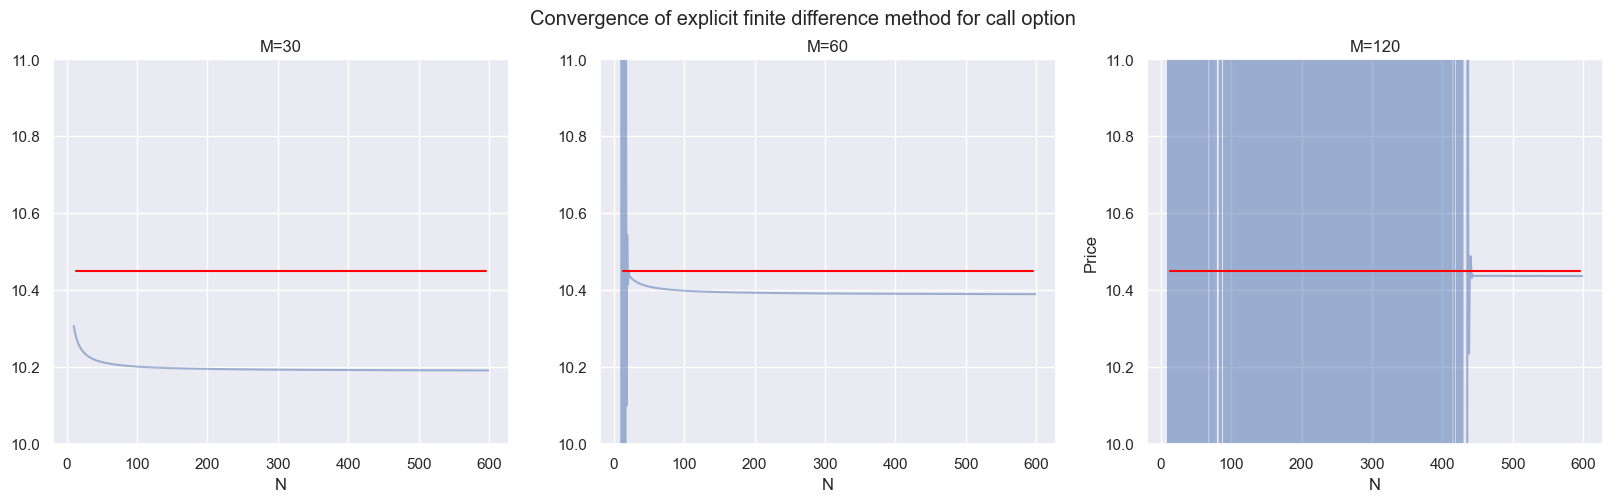

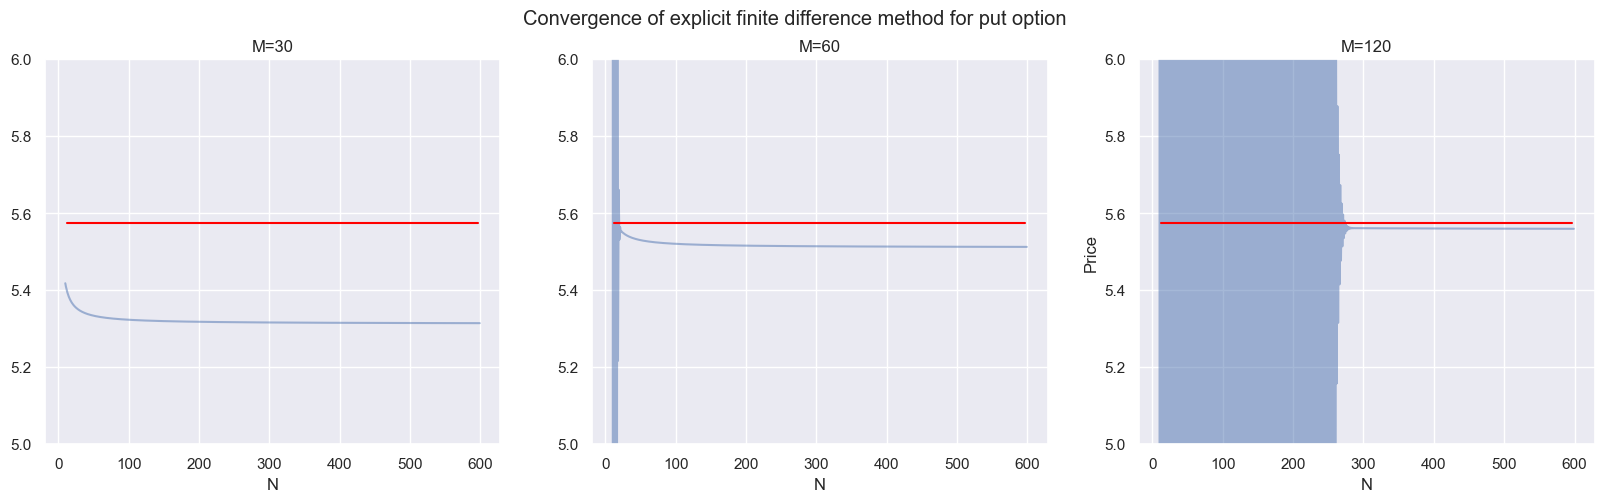

In [ ]:
Ms = [30, 60, 120]
Ns = np.arange(10, 600, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("call")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_call(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(10, 11)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of explicit finite difference method for call option")
plt.show()

i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("put")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_put(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(5, 6)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of explicit finite difference method for put option")
plt.show()

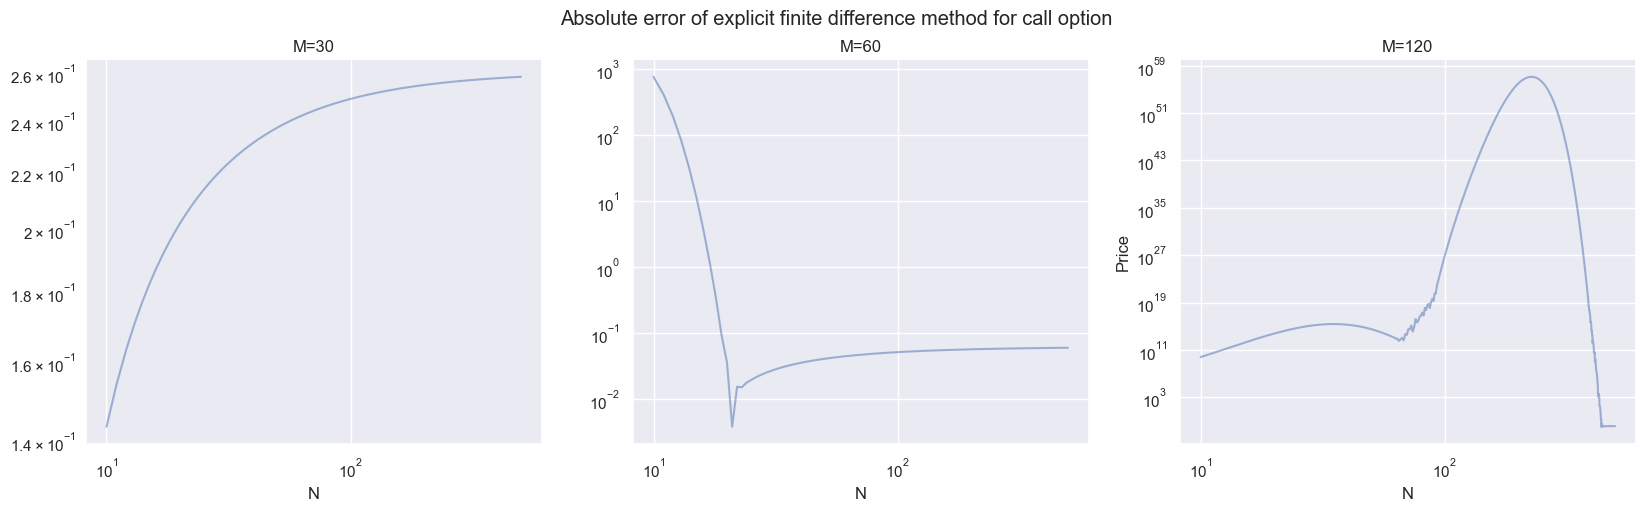

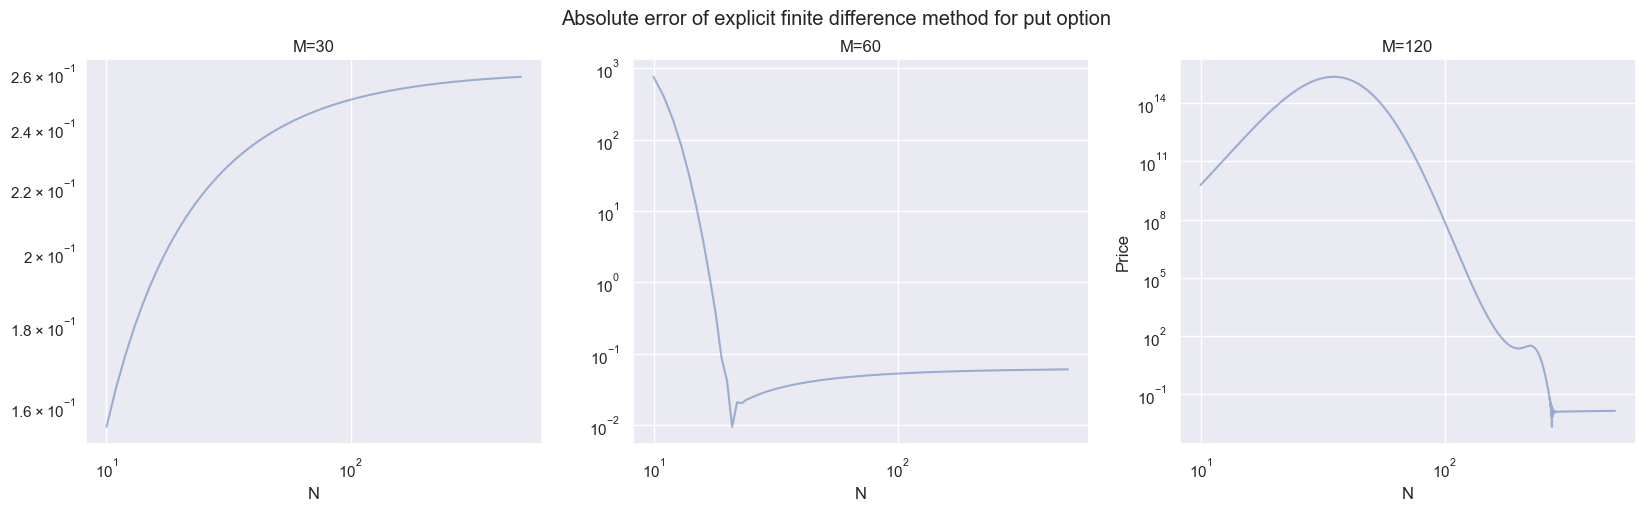

In [ ]:
Ms = [30, 60, 120]
Ns = np.arange(10, 500, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("call")
        errors.append(np.abs(fdm.error("call")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of explicit finite difference method for call option")
plt.show()
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("put")
        errors.append(np.abs(fdm.error("put")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of explicit finite difference method for put option")
plt.show()


In [124]:
Ms = [30, 60, 120]
Ns = np.arange(10, 500, 1)
print("Call")
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("call")
        errors.append(np.abs(fdm.error("call")))
    errors = np.array(errors)
    print(f"Ns for which the absolute error is less than 0.2: {np.where(errors<0.2)[0]+10}, M={M}")
print("Put")
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("put")
        errors.append(np.abs(fdm.error("put")))
    errors = np.array(errors)
    print(f"Ns for which the absolute error is less than 0.2: {np.where(errors<0.2)[0]+10}, M={M}")

Call
Ns for which the absolute error is less than 0.2: [10 11 12 13 14 15 16 17 18 19], M=30
Ns for which the absolute error is less than 0.2: [ 19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 2

## 3.2. Implicit finite difference scheme

Implement the implicit finite difference method for the same European option.

Tasks:

• Perform backward time stepping by solving a tridiagonal linear system at every time step.

• Evaluate how convergence compares against the explicit scheme.

• Analyse the cost of solving a linear system and interpret the computational trade-offs.

Key question: how does the implicit scheme address the stability limitations of the explicit
method, and what computational costs arise as a consequence?


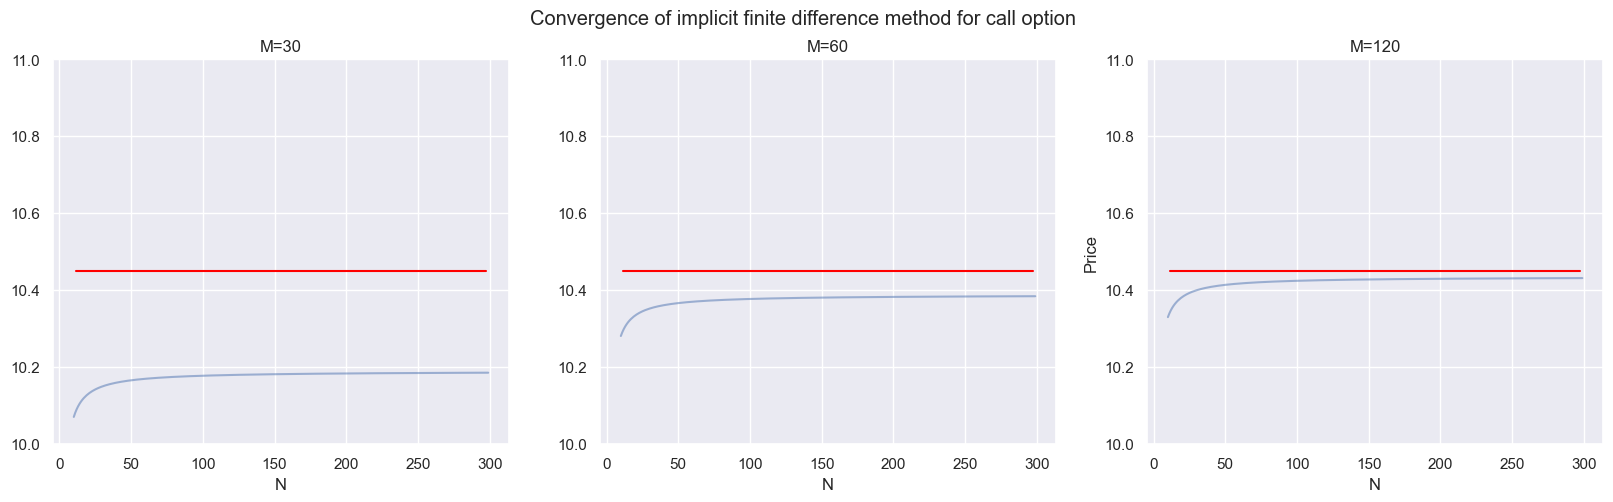

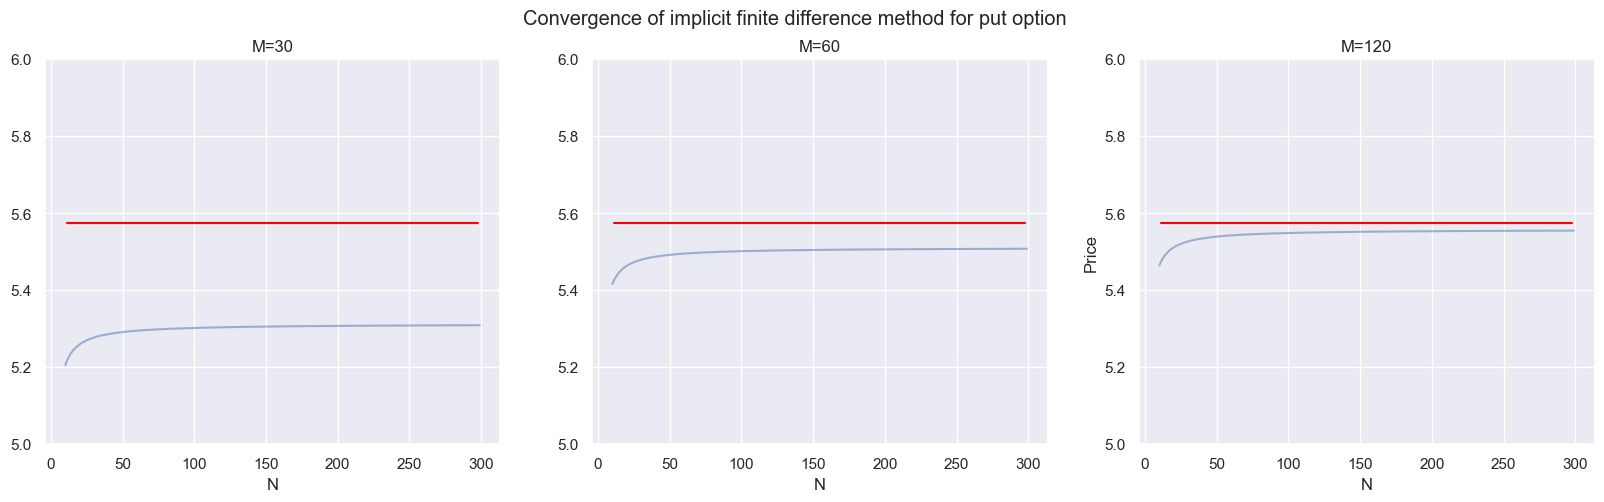

In [ ]:
### Parameters
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.2
Ms = [30, 60, 120]
Ns = np.arange(10, 300, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("call")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_call(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(10, 11)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of implicit finite difference method for call option")
plt.show()

i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("put")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_put(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(5, 6)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of implicit finite difference method for put option")
plt.show()

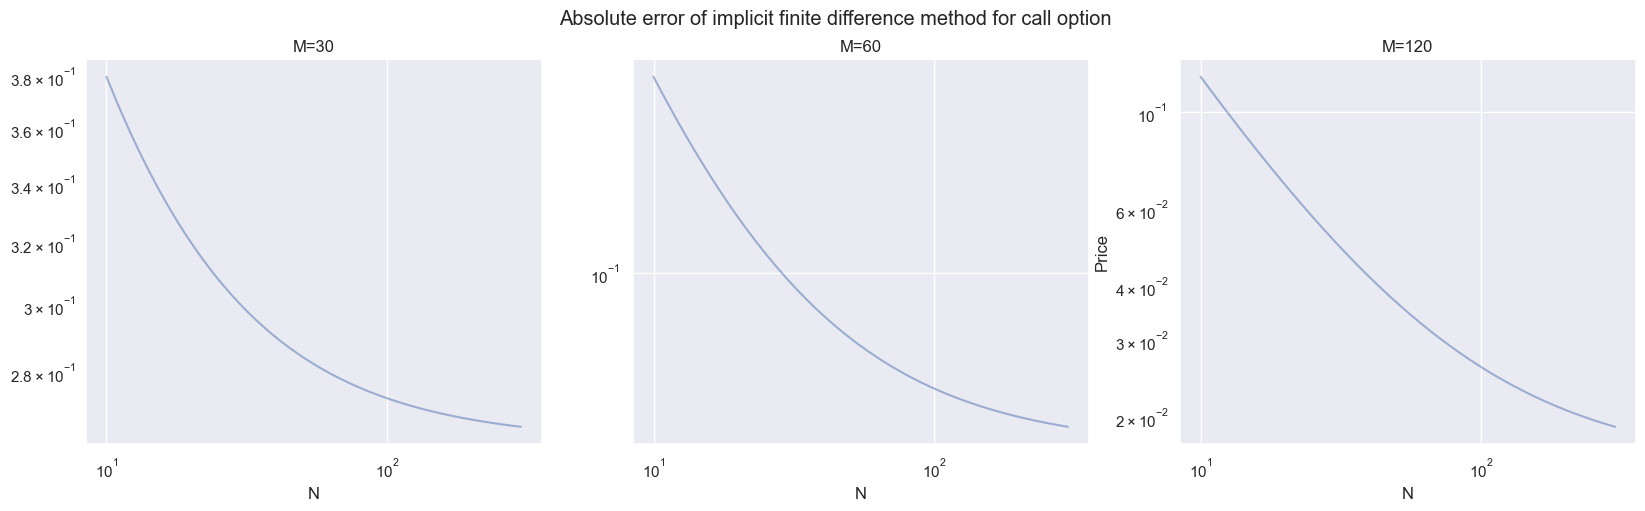

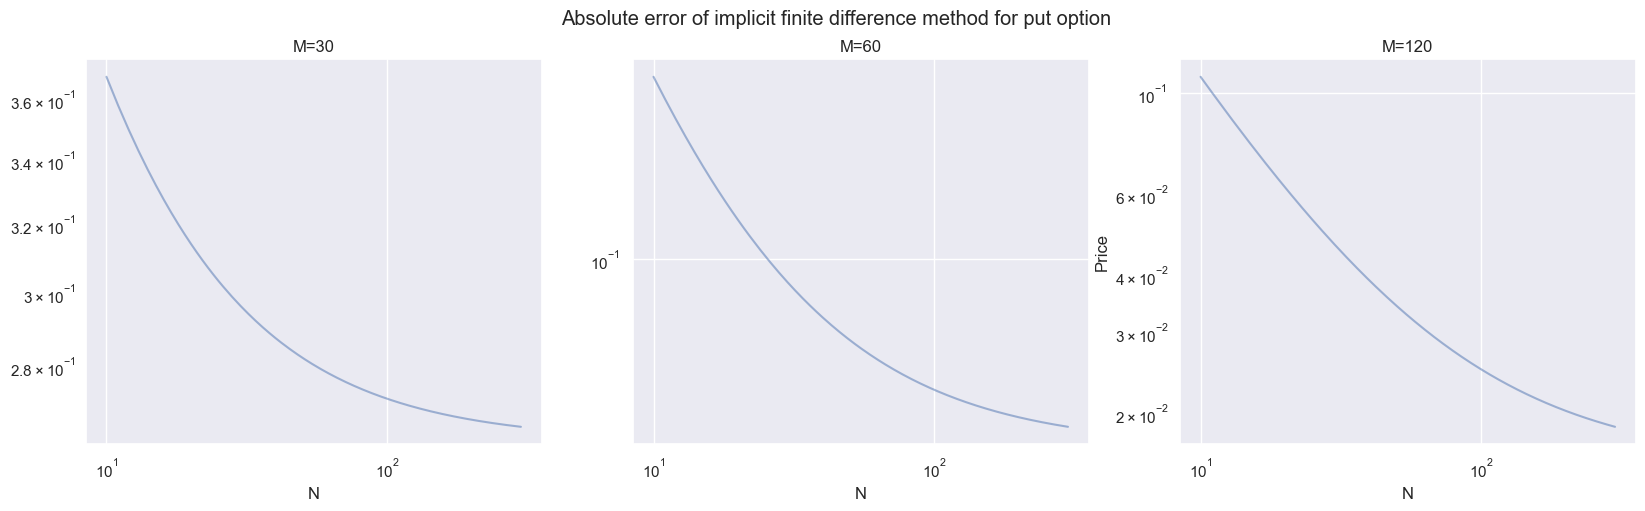

In [ ]:
Ms = [30, 60, 120]
Ns = np.arange(10, 300, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("call")
        errors.append(np.abs(fdm.error("call")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of implicit finite difference method for call option")
plt.show()
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("put")
        errors.append(np.abs(fdm.error("put")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of implicit finite difference method for put option")
plt.show()


## 3.3. Crank–Nicolson scheme

Implement the Crank–Nicolson finite difference scheme, combining the explicit and implicit
formulations.

Tasks:

• Implement the method and compute the solution on a grid identical to the previous experiments.

• Compare the accuracy and stability against explicit and implicit results.

• Analyse the convergence rate and relate it to expected second order accuracy in both time
and space.

Key question: does Crank–Nicolson achieve a practical compromise between accuracy and
stability, or are there parameter configurations where it underperforms?


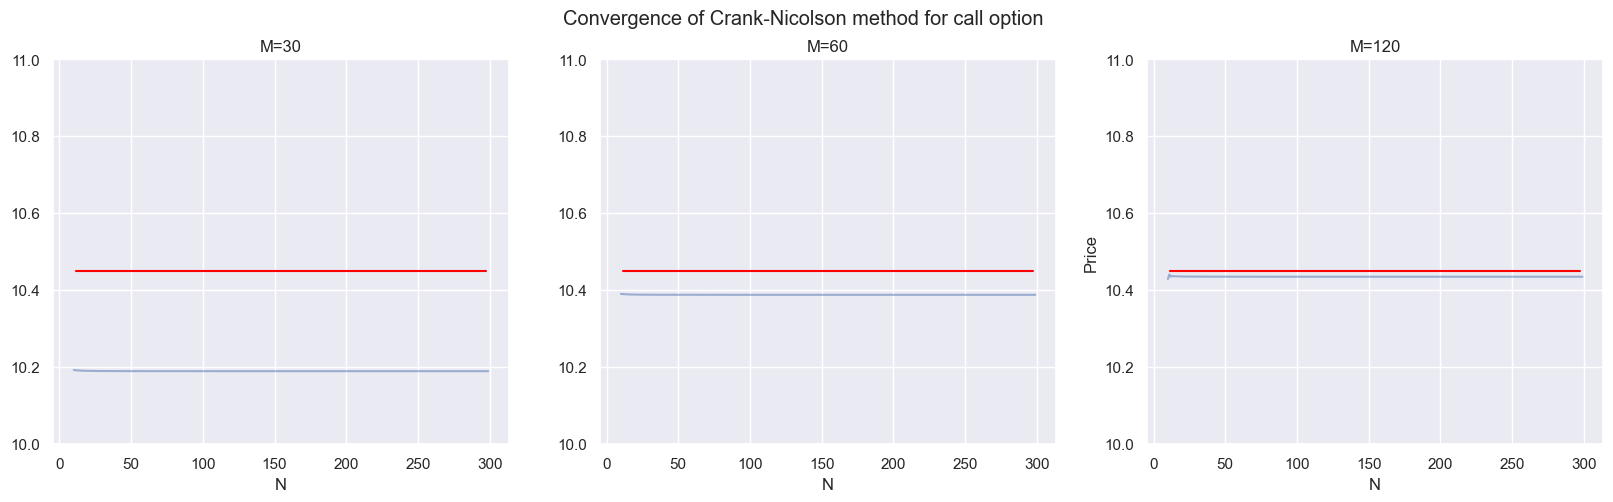

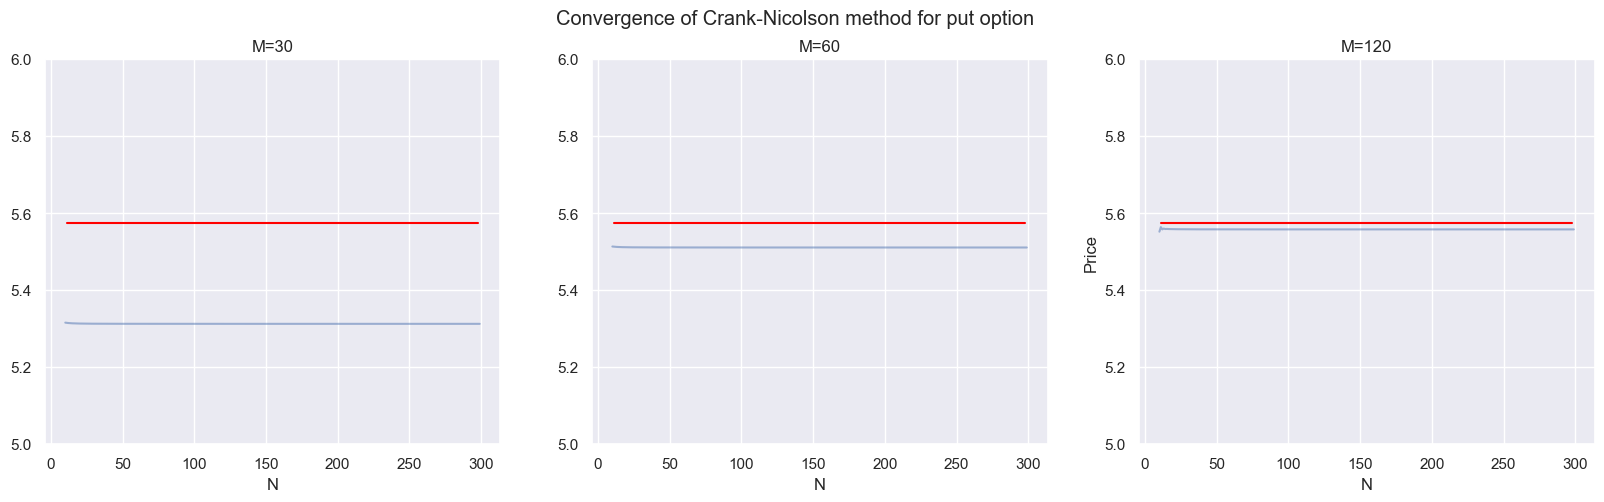

In [126]:
### Parameters
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.2
Ms = [30, 60, 120]
Ns = np.arange(10, 300, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("call")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_call(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(10, 11)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of Crank-Nicolson method for call option")
plt.show()

i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    prices = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("put")
        prices.append(fdm.price())

    ax[i].plot(Ns, prices, alpha=0.5)
    ax[i].axhline(fdm.bs_put(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(5, 6)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of Crank-Nicolson method for put option")
plt.show()

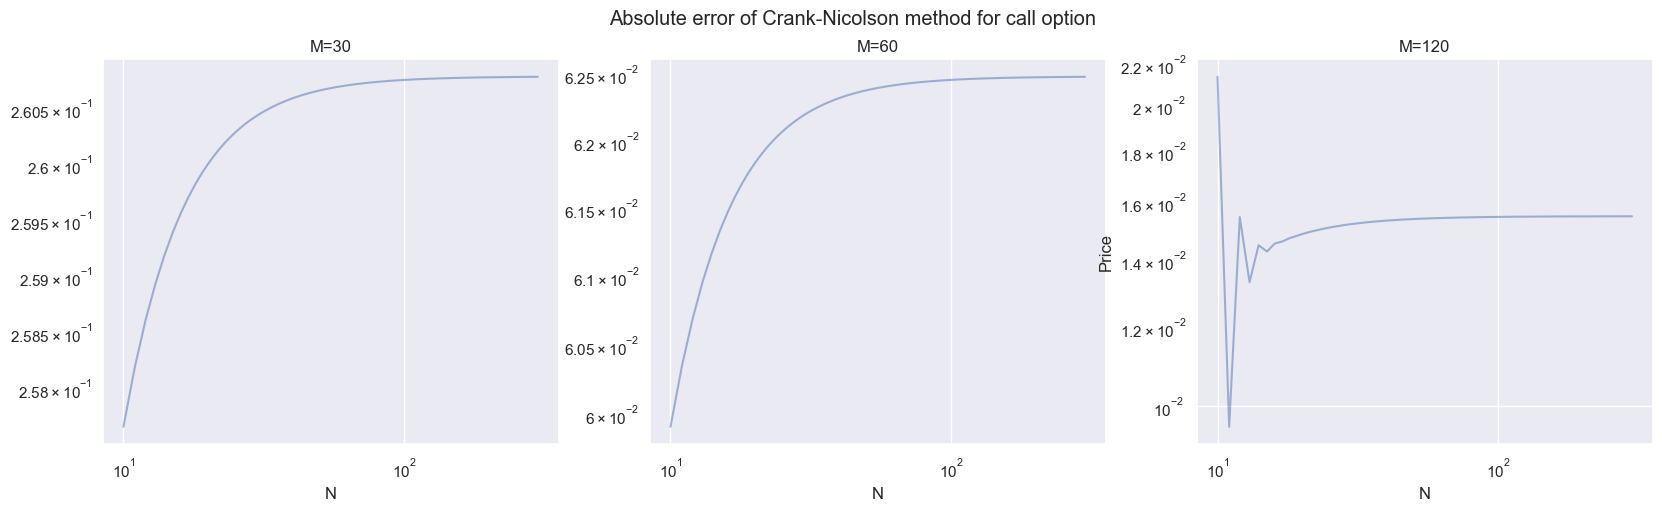

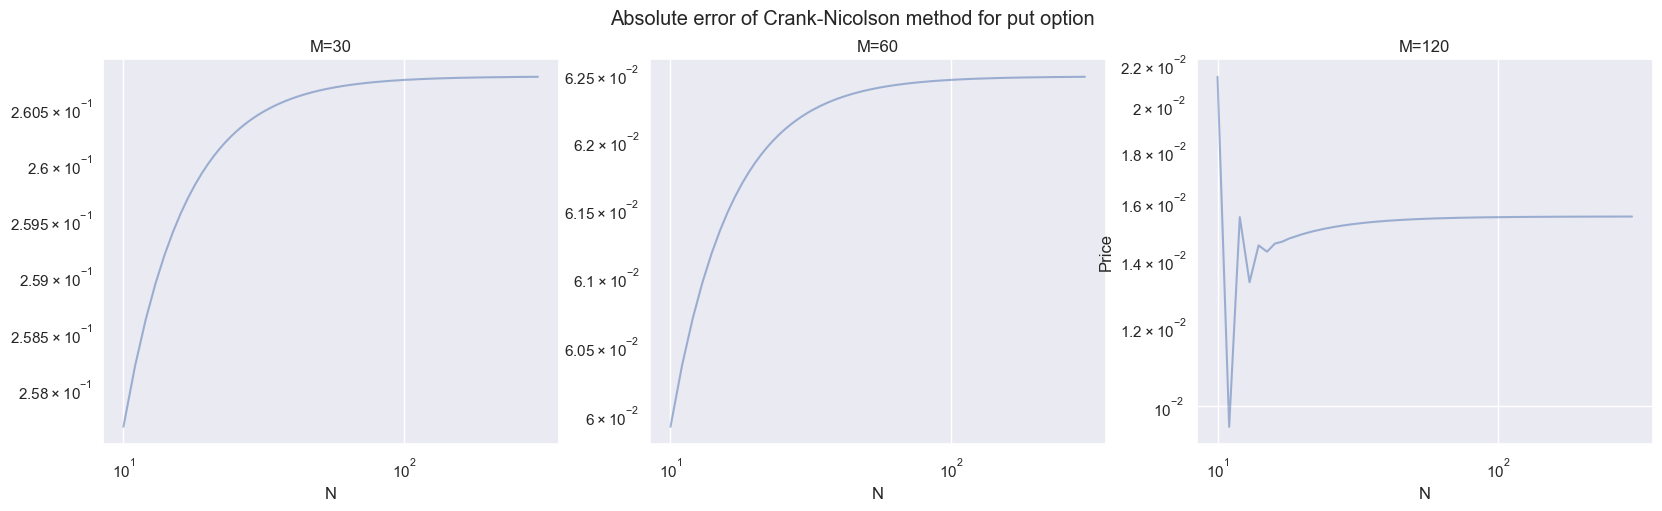

In [ ]:
Ms = [30, 60, 120]
Ns = np.arange(10, 300, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("call")
        errors.append(np.abs(fdm.error("call")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of Crank-Nicolson method for call option")
plt.show()
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    errors = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("put")
        errors.append(np.abs(fdm.error("put")))

    ax[i].loglog(Ns, errors, alpha=0.5)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    i += 1
plt.ylabel("Error")
plt.suptitle("Absolute error of Crank-Nicolson method for put option")
plt.show()


## Comparison of methods

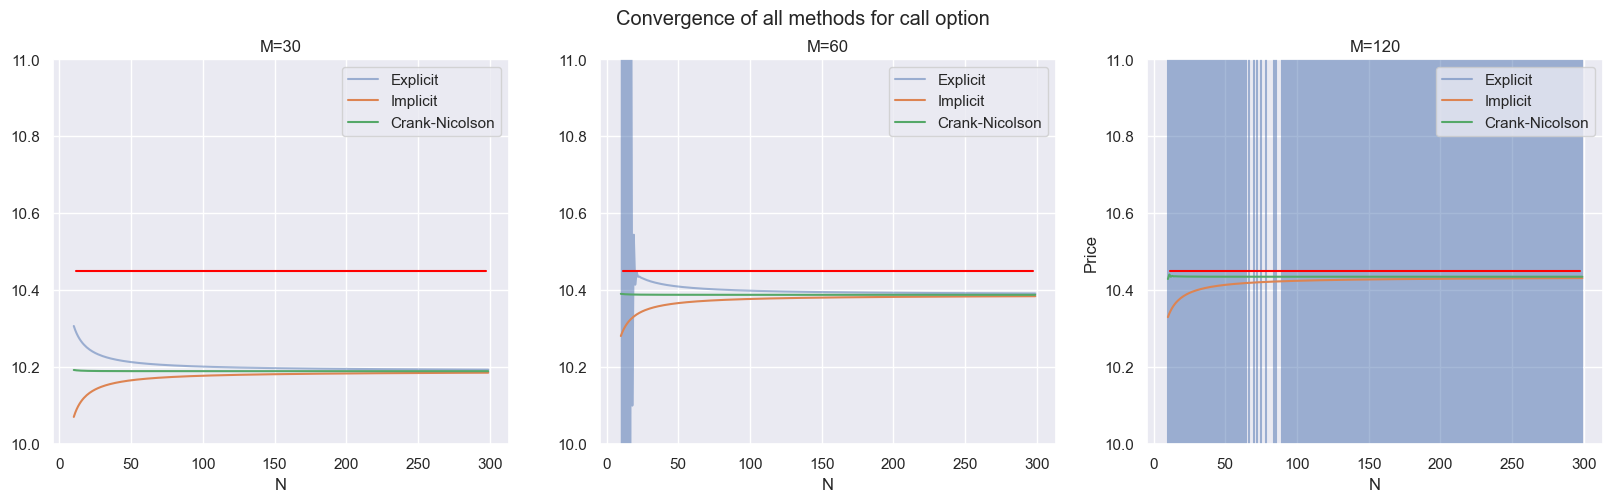

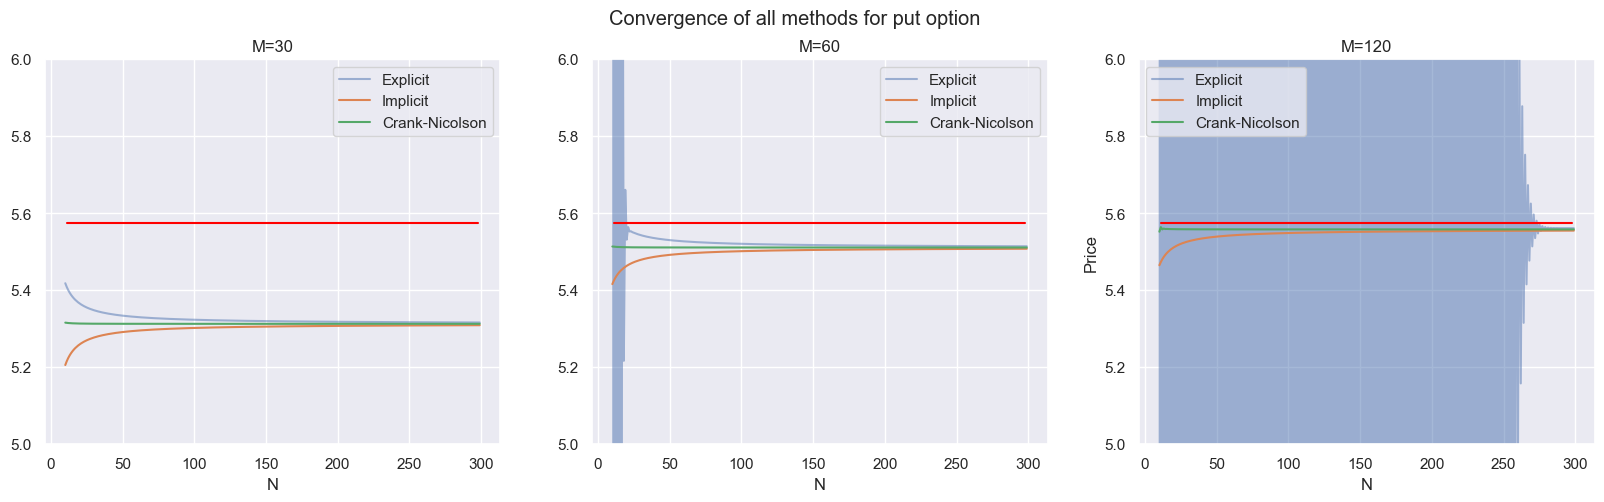

In [5]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.2
Ms = [30, 60, 120]
Ns = np.arange(10, 300, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    explicit = []
    implicit = []
    cn = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("call")
        explicit.append(fdm.price())
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("call")
        implicit.append(fdm.price())
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("call")
        cn.append(fdm.price())

    ax[i].plot(Ns, explicit, alpha=0.5, label='Explicit')
    ax[i].plot(Ns, implicit, label='Implicit')
    ax[i].plot(Ns, cn, label='Crank-Nicolson')
    ax[i].axhline(fdm.bs_call(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(10, 11)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    ax[i].legend()
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of all methods for call option")
plt.show()

i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
for M in Ms:
    explicit = []
    implicit = []
    cn = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("put")
        explicit.append(fdm.price())
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("put")
        implicit.append(fdm.price())
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("put")
        cn.append(fdm.price())

    ax[i].plot(Ns, explicit, alpha=0.5, label='Explicit')
    ax[i].plot(Ns, implicit, label='Implicit')
    ax[i].plot(Ns, cn, label='Crank-Nicolson')
    ax[i].axhline(fdm.bs_put(), xmin=0.05, xmax=0.95, color='red')
    ax[i].set_ylim(5, 6)
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    ax[i].legend()
    i += 1
plt.ylabel("Price")
plt.suptitle("Convergence of all methods for put option")
plt.show()

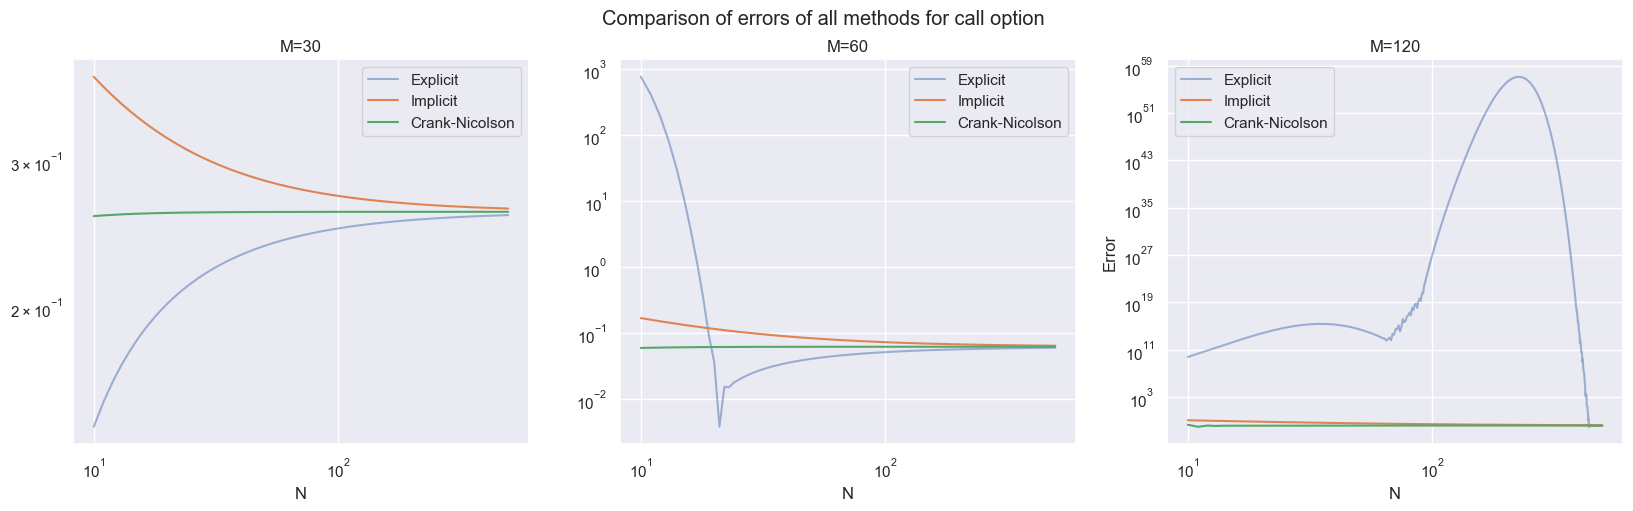

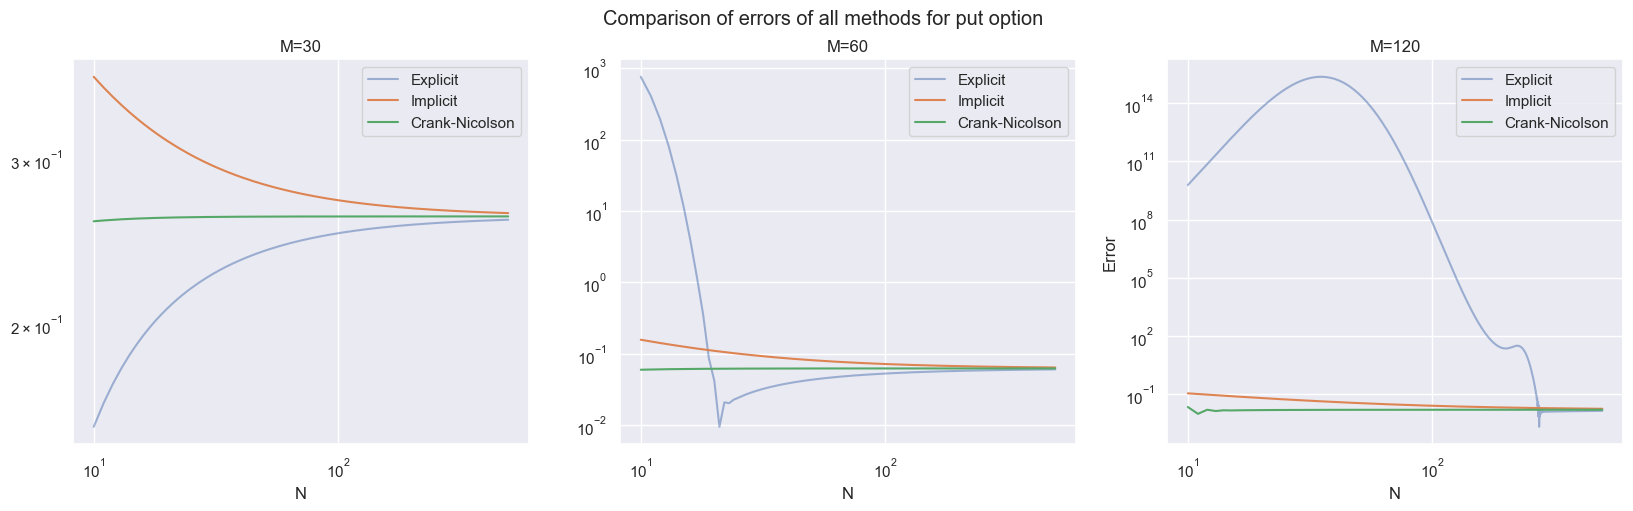

In [34]:
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.2
Ms = [30, 60, 120]
Ns = np.arange(10, 500, 1)
i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
plt.ylabel("Error")
for M in Ms:
    explicit = []
    implicit = []
    cn = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("call")
        explicit.append(np.abs(fdm.error("call")))
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("call")
        implicit.append(np.abs(fdm.error("call")))
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("call")
        cn.append(np.abs(fdm.error("call")))

    ax[i].loglog(Ns, explicit, alpha=0.5, label='Explicit')
    ax[i].loglog(Ns, implicit, label='Implicit')
    ax[i].loglog(Ns, cn, label='Crank-Nicolson')
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    ax[i].legend()
    i += 1
plt.suptitle("Comparison of errors of all methods for call option")
plt.show()

i=0
fig, ax = plt.subplots(1, 3, figsize=(20,5))
plt.ylabel("Error")
for M in Ms:
    explicit = []
    implicit = []
    cn = []
    for N in Ns:
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.explicit("put")
        explicit.append(np.abs(fdm.error("put")))
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.implicit("put")
        implicit.append(np.abs(fdm.error("put")))
        fdm = FDM(S0, K, T, r, sigma, M, N)
        fdm.crank_nicolson("put")
        cn.append(np.abs(fdm.error("put")))

    ax[i].loglog(Ns, explicit, alpha=0.5, label='Explicit')
    ax[i].loglog(Ns, implicit, label='Implicit')
    ax[i].loglog(Ns, cn, label='Crank-Nicolson')
    ax[i].set_xlabel("N")
    ax[i].set_title(f"M={M}")
    ax[i].legend()
    i += 1
plt.suptitle("Comparison of errors of all methods for put option")
plt.show()

- Explicit scheme

The Explicit Finite Difference Scheme is the simplest to implement, calculating the option price at the next time step directly from the prices at the current step. However, it is only conditionally stable, requiring the time step $\Delta t$ to be very small, proportional to $(\Delta S)^2$. Its accuracy limits its use in production environments where speed and high precision are needed.

- Implicit scheme

The Implicit Finite Difference Scheme solves the stability issue by being unconditionally stable, allowing for much larger time steps determined only by accuracy requirements.  The ability to use large $\Delta t$ often makes the implicit scheme faster overall than the explicit one. For the same parameters it's slower than explicit scheme but provides better accuracy.

- Crank-Nicolson scheme

The Crank–Nicolson scheme is the best compromise, offering superior accuracy without sacrificing stability, making it a widely preferred method in financial engineering. However, under some circumstances the method can produce oscillations near the expiry date.

In [ ]:
def crank_nicolson_barrier(self, option='call', barrier=None, barrier_type=None):
    if barrier is not None:
        iB = int(barrier / self.dS)
    else:
        iB = None 
    for i in range(self.M + 1):
        S = self.S_vals[i]
        if barrier is not None:
            if barrier_type == 'down-and-out' and S <= barrier:
                self.grid[i, self.N] = 0.0
                continue
            elif barrier_type == 'up-and-out' and S >= barrier:
                self.grid[i, self.N] = 0.0
                continue
        if option == 'call':
            self.grid[i, self.N] = max(S - self.K, 0.0)
        else:
            self.grid[i, self.N] = max(self.K - S, 0.0)
    for j in range(self.N - 1, -1, -1):
        if barrier is None:
            i_start, i_end = 1, self.M - 1
        elif barrier_type == 'down-and-out':
            i_start, i_end = iB + 1, self.M - 1
        elif barrier_type == 'up-and-out':
            i_start, i_end = 1, iB - 1
        n = i_end - i_start + 1  
        if n <= 0:
            continue  
        a = np.zeros(n)
        b = np.zeros(n)
        c = np.zeros(n)
        d = np.zeros(n)
        for k in range(n):
            i = i_start + k
            a[k] = -0.25 * self.dt * (self.sigma**2 * i**2 - self.r * i)
            b[k] = 1 + 0.5 * self.dt * (self.sigma**2 * i**2 + self.r)
            c[k] = -0.25 * self.dt * (self.sigma**2 * i**2 + self.r * i)
            d[k] = (
                0.25 * self.dt * (self.sigma**2 * i**2 - self.r * i) * self.grid[i-1, j+1]
                + (1 - 0.5 * self.dt * (self.sigma**2 * i**2 + self.r)) * self.grid[i, j+1]
                + 0.25 * self.dt * (self.sigma**2 * i**2 + self.r * i) * self.grid[i+1, j+1]
            )
        if barrier is not None:
            if barrier_type == 'down-and-out':
                d[0] -= a[0] * 0.0  
                tau = self.T - self.T_vals[j]
                Vmax = self.sMax - self.K * np.exp(-self.r * tau) if option=='call' else 0.0
                d[-1] -= c[-1] * Vmax
            elif barrier_type == 'up-and-out':
                d[-1] -= c[-1] * 0.0  
                d[0] -= a[0] * 0.0   
        else:
            if option == 'call':
                d[0] -= a[0]*0.0
                tau = self.T - self.T_vals[j]
                Vmax = self.sMax - self.K*np.exp(-self.r*tau)
                d[-1] -= c[-1]*Vmax
            else:
                tau = self.T - self.T_vals[j]
                d[0] -= a[0]*self.K*np.exp(-self.r*tau)
                d[-1] -= c[-1]*0.0
        cp = np.zeros(n)
        dp = np.zeros(n)
        x = np.zeros(n)
        cp[0] = c[0]/b[0]
        dp[0] = d[0]/b[0]
        for k in range(1, n):
            denom = b[k] - a[k]*cp[k-1]
            cp[k] = c[k]/denom
            dp[k] = (d[k] - a[k]*dp[k-1])/denom
        x[-1] = dp[-1]
        for k in range(n-2, -1, -1):
            x[k] = dp[k] - cp[k]*x[k+1]
        for k in range(n):
            i = i_start + k
            self.grid[i, j] = x[k]
        if barrier is not None:
            if barrier_type == 'down-and-out':
                self.grid[iB, j] = 0.0
                self.grid[self.M, j] = Vmax if option=='call' else 0.0
                self.grid[0:j] = 0.0
            elif barrier_type == 'up-and-out':
                self.grid[iB, j] = 0.0
                self.grid[0, j] = 0.0
        else:
            self.grid[0, j] = 0.0 if option=='call' else self.K*np.exp(-self.r*(self.T-self.T_vals[j]))
            self.grid[self.M, j] = Vmax if option=='call' else 0.0